### 17th August 2026

## LAB 4- Polynomial and Multiple Regression

#### Anirvin Iyer
#### 240905318
#### CSE D- 32

### Questions 1

**a.** Create a CSV file with sample data.

**b.** Write a Python function program to:
- Find the fitted simple linear and polynomial regression equations for the given data.

**c.** Compare the coefficients obtained from manually intuitive and matrix formulation methods with your program.

**d.** Plot the scatterplot of the raw data and then another scatterplot with lines pertaining to a linear fit and a quadratic fit overlaid.

**e.** Compute the error, MSE, and RMSE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
df=pd.read_csv("Yield.csv")
x = df["Temp (X)"].values
y = df["Yield (Y)"].values

n = len(x)

print(df)

    Temp (X)  Yield (Y)
0         50        3.3
1         50        2.8
2         50        2.9
3         70        2.3
4         70        2.6
5         70        2.1
6         80        2.5
7         80        2.9
8         80        2.4
9         90        3.0
10        90        3.1
11        90        2.8
12       100        3.3
13       100        3.5
14       100        3.0


In [13]:
def pedhazur_linear(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)

    b1 = numerator / denominator
    b0 = y_mean - b1 * x_mean

    return b0, b1


b0_ped, b1_ped = pedhazur_linear(x, y)

print("Pedhazur Method")
print(f"b0 = {b0_ped:.6f}")
print(f"b1 = {b1_ped:.6f}")

print(f"\nLinear Regression Equation:")
print(f"y = {b0_ped:.6f} + {b1_ped:.6f}x")

Pedhazur Method
b0 = 2.306306
b1 = 0.006757

Linear Regression Equation:
y = 2.306306 + 0.006757x


In [17]:
X = np.column_stack((np.ones(len(x)), x))
B=np.linalg.inv(X.T@X)@X.T@y

print("Linear Matrix: ")
print(B)



X2=np.column_stack((np.ones(len(x)), x, x**2))
B2 = np.linalg.inv(X2.T @ X2) @ X2.T @ y

print("\nQuadratic:")
print(B2)

Linear Matrix: 
[2.30630631 0.00675676]

Quadratic:
[ 7.96048110e+00 -1.53711340e-01  1.07560137e-03]


In [19]:
print("Pedhazur:", [b0_ped, b1_ped])
print("Matrix:  ", B)
print("Quadratic:", B2)

Pedhazur: [2.306306306306306, 0.006756756756756758]
Matrix:   [2.30630631 0.00675676]
Quadratic: [ 7.96048110e+00 -1.53711340e-01  1.07560137e-03]


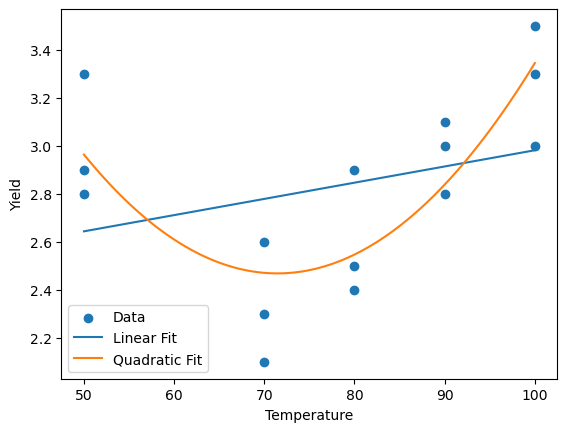

In [22]:
xp = np.linspace(min(x), max(x), 100)

yp1 = b0_ped + b1_ped*xp
yp2 = B2[0] + B2[1]*xp + B2[2]*xp**2

plt.scatter(x, y, label="Data")
plt.plot(xp, yp1, label="Linear Fit")
plt.plot(xp, yp2, label="Quadratic Fit")

plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.legend()
plt.show()

In [23]:
y1 = b0_ped + b1_ped*x
y2 = B2[0] + B2[1]*x + B2[2]*x**2

for name, pred in [("Linear", y1), ("Quadratic", y2)]:
    error = y - pred
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)
    
    print(name)
    print("Error:", error)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print()

Linear
Error: [ 0.65585586  0.15585586  0.25585586 -0.47927928 -0.17927928 -0.67927928
 -0.34684685  0.05315315 -0.44684685  0.08558559  0.18558559 -0.11441441
  0.31801802  0.51801802  0.01801802]
MSE: 0.13270870870870877
RMSE: 0.36429206511905904

Quadratic
Error: [ 0.33608247 -0.16391753 -0.06391753 -0.17113402  0.12886598 -0.37113402
 -0.04742268  0.35257732 -0.14742268  0.16116838  0.26116838 -0.03883162
 -0.04536082  0.15463918 -0.34536082]
MSE: 0.047784650630011485
RMSE: 0.2185970050801508



### Question 2

**a.** Create a CSV file with sample data.

**b.** Write a Python function program to:
- Find the fitted multiple linear regression equation for the given data.

**c.** Compare the coefficients obtained using intuitive and matrix formulation methods with your program.

**d.** Plot the data adorned with the estimated regression equation.

**e.** Compute the error, MSE, and RMSE.



In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Infarct": [0.119,0.190,0.395,0.469,0.130,0.311,0.418,0.480,0.687,0.847,
                0.062,0.122,0.033,0.102,0.206,0.249,0.220,0.299,0.350,0.350,0.588,
                0.379,0.149,0.316,0.390,0.429,0.477,0.439,0.446,0.538,0.625,0.974],
    
    "Area": [0.34,0.64,0.76,0.83,0.73,0.82,0.95,1.06,1.20,1.47,
             0.44,0.77,0.90,1.07,1.01,1.03,1.16,1.21,1.20,1.22,0.99,
             0.77,1.05,1.06,1.02,0.99,0.97,1.12,1.23,1.19,1.22,1.40],

    "X2": [0]*10 + [1]*11 + [0]*11,
    "X3": [0]*21 + [1]*11
})

df.to_csv("rabbit_data.csv", index=False)

df

,Infarct,Area,X2,X3
0,0.119,0.34,0,0
1,0.190,0.64,0,0
2,0.395,0.76,0,0
3,0.469,0.83,0,0
4,0.130,0.73,0,0
5,0.311,0.82,0,0
6,0.418,0.95,0,0
7,0.480,1.06,0,0
8,0.687,1.20,0,0
9,0.847,1.47,0,0


In [34]:
y = df["Infarct"].values
x1 = df["Area"].values
x2 = df["X2"].values
x3 = df["X3"].values

# Correlation coefficients
r_y1 = np.corrcoef(y, x1)[0, 1]
r_y2 = np.corrcoef(y, x2)[0, 1]
r_y3 = np.corrcoef(y, x3)[0, 1]

r_12 = np.corrcoef(x1, x2)[0, 1]
r_13 = np.corrcoef(x1, x3)[0, 1]
r_23 = np.corrcoef(x2, x3)[0, 1]

# Pedhazur equations
D = 1 + 2*r_12*r_13*r_23 - r_12**2 - r_13**2 - r_23**2

beta1 = (r_y1*(1-r_23**2) - r_y2*(r_12-r_13*r_23)
         + r_y3*(r_12*r_23-r_13)) / D

beta2 = (r_y2*(1-r_13**2) - r_y1*(r_12-r_13*r_23)
         + r_y3*(r_12*r_13-r_23)) / D

beta3 = (r_y3*(1-r_12**2) - r_y1*(r_13-r_12*r_23)
         + r_y2*(r_12*r_13-r_23)) / D

# Convert standardized coefficients to raw coefficients
b1 = beta1 * np.std(y) / np.std(x1)
b2 = beta2 * np.std(y) / np.std(x2)
b3 = beta3 * np.std(y) / np.std(x3)

b0 = np.mean(y) - b1*np.mean(x1) - b2*np.mean(x2) - b3*np.mean(x3)

print("Pedhazur Method")
print("b0 =", b0)
print("b1 =", b1)
print("b2 =", b2)
print("b3 =", b3)

Pedhazur Method
b0 = -0.1345363782360121
b1 = 0.6126549752681957
b2 = -0.24348223339581984
b3 = -0.06565569473887078


In [31]:
y = df["Infarct"].values
x1 = df["Area"].values
x2 = df["X2"].values
x3 = df["X3"].values

X = np.column_stack((np.ones(len(y)), x1, x2, x3))

B = np.linalg.inv(X.T @ X) @ X.T @ y

print("Regression coefficients:")
print("b0 =", B[0])
print("b1 =", B[1])
print("b2 =", B[2])
print("b3 =", B[3])

Regression coefficients:
b0 = -0.13453637823601383
b1 = 0.6126549752681979
b2 = -0.24348223339582045
b3 = -0.06565569473887137


In [36]:
comparison = pd.DataFrame({
    "Coefficient": ["b0", "b1", "b2", "b3"],
    "Pedhazur": B_ped,
    "Matrix": B_matrix
})

comparison

,Coefficient,Pedhazur,Matrix
0,b0,-0.134536,-0.134536
1,b1,0.612655,0.612655
2,b2,-0.243482,-0.243482
3,b3,-0.065656,-0.065656


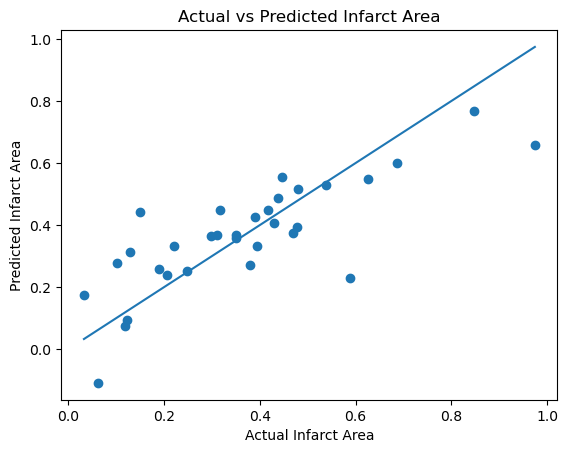

In [41]:
y_pred = X @ B_matrix

plt.scatter(y, y_pred)

plt.xlabel("Actual Infarct Area")
plt.ylabel("Predicted Infarct Area")
plt.title("Actual vs Predicted Infarct Area")

plt.plot([min(y), max(y)], [min(y), max(y)])
plt.show()

In [30]:
error = y - y_pred

mse = np.mean(error**2)
rmse = np.sqrt(mse)

print("Error:")
print(error)

print("\nMSE =", mse)
print("RMSE =", rmse)

Error:
[ 0.04523369 -0.06756281  0.0639186   0.09503275 -0.18270175 -0.0568407
 -0.02948585 -0.0348779   0.08635041  0.08093356  0.17045042  0.02827428
 -0.14037087 -0.17552221 -0.03476291 -0.00401601 -0.11266116 -0.06429391
 -0.00716736 -0.01942046  0.35949019  0.10744774 -0.29409565 -0.1332222
 -0.034716    0.02266365  0.08291675 -0.0469815  -0.10737355  0.00913265
  0.077753    0.31647511]

MSE = 0.017028422624564204
RMSE = 0.13049299837372197
